# Étape 1 — Chargement et préparation des données (MVTec AD — `pill`)

TP B6, partie 1. Objectif : charger la catégorie `pill`, redimensionner, normaliser dans `[0, 1]`, réserver une fraction des saines pour la validation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from indusense.vision.dataset import (
    DEFAULT_IMAGE_SIZE,
    list_defects,
    load_defect_images,
    load_good_images,
    train_val_split,
)

IMAGE_SIZE = DEFAULT_IMAGE_SIZE
SEED = 42
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
good_train = load_good_images("train", IMAGE_SIZE)
good_train, good_val = train_val_split(good_train, val_fraction=0.15, seed=SEED)
good_test = load_good_images("test", IMAGE_SIZE)

defects = list_defects()
print(f"Défauts disponibles : {defects}")
print(f"Saines train : {good_train.shape} | Saines val : {good_val.shape} | Saines test : {good_test.shape}")
print(f"min={good_train.min():.3f} max={good_train.max():.3f} dtype={good_train.dtype}")

Défauts disponibles : ['color', 'combined', 'contamination', 'crack', 'faulty_imprint', 'pill_type', 'scratch']
Saines train : (227, 256, 256, 3) | Saines val : (40, 256, 256, 3) | Saines test : (26, 256, 256, 3)
min=0.016 max=0.969 dtype=float32


## Livrable — saines vs défauts après chargement/normalisation

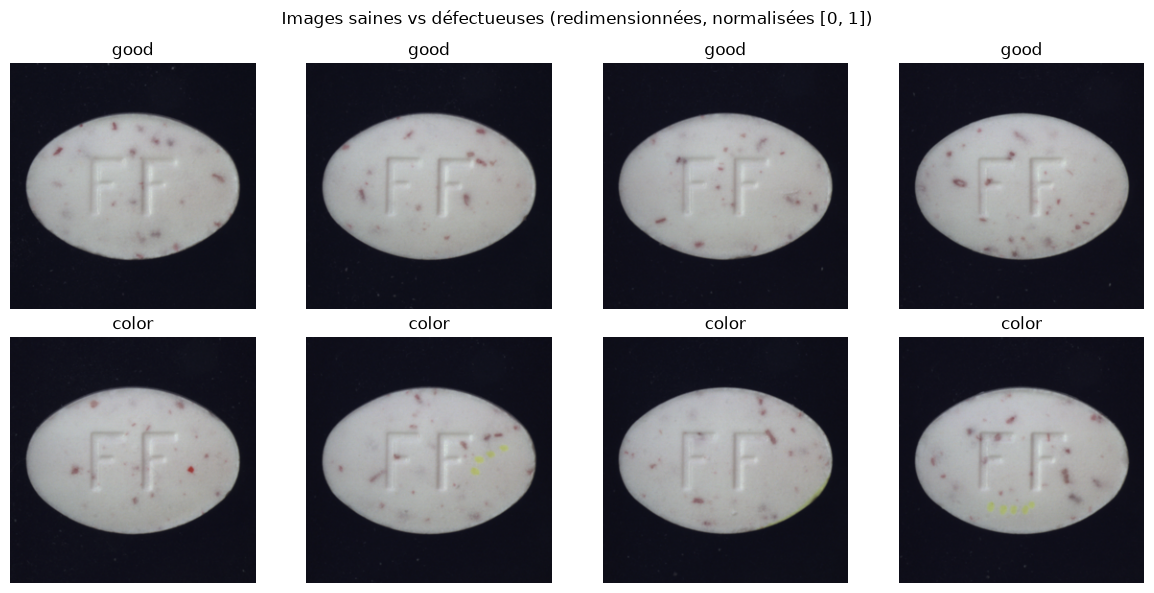

In [3]:
n_show = 4
sample_defect = defects[0]
defect_images = load_defect_images(sample_defect, IMAGE_SIZE)

fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(good_test[i])
    axes[0, i].set_title("good")
    axes[0, i].axis("off")
    axes[1, i].imshow(defect_images[i])
    axes[1, i].set_title(sample_defect)
    axes[1, i].axis("off")
fig.suptitle("Images saines vs défectueuses (redimensionnées, normalisées [0, 1])")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_sain_vs_defaut.png", dpi=150)
plt.show()